In [177]:
"""
SAM-Med3D Segmentation Visualization (FIXED)

FIXES:
1. ✅ CORONAL view (front-to-back) instead of axial
2. ✅ Proper normalization for SAM input (fixes red segmentation issue)
3. ✅ Resize-then-pad preprocessing (zero data loss)
"""

'\nSAM-Med3D Segmentation Visualization (FIXED)\n\nFIXES:\n1. ✅ CORONAL view (front-to-back) instead of axial\n2. ✅ Proper normalization for SAM input (fixes red segmentation issue)\n3. ✅ Resize-then-pad preprocessing (zero data loss)\n'

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
import random
import yaml
import torch.nn.functional as F
from multiview_plotting import plot_all_anatomical_views, plot_single_view

In [179]:
# Add project root to path (Notebook-compatible)
project_root = Path.cwd().parent  # Assumes we're in notebooks/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [180]:
from med3pipe.sam.core import build_sam3d_model, find_default_sam3d_root
from med3pipe.sam.transforms import ResizeLargestTo
import torchio as tio

In [181]:
print(f"✅ Project root: {project_root}")

✅ Project root: c:\Users\cahel\Desktop\Med3Tab-PFN


============================================================================
Configuration
============================================================================

In [182]:
config_path = project_root / "configs" / "datasets.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

In [183]:
sam3d_root = find_default_sam3d_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 128
n_samples_per_dataset = 2

In [184]:
# Optional: Manually specify checkpoint path (set to None for auto-detection)
MANUAL_CHECKPOINT = Path("../SAM-Med3D-main/SAM-Med3D-main/ckpt/sam_med3d_turbo.pth")

In [185]:
# SAM Segmentation Settings
USE_SINGLE_POINT_PROMPT = True  # True = less over-segmentation, False = more complete segmentation
SEGMENTATION_THRESHOLD = 0.5    # Increase to 0.7 or 0.8 if SAM over-segments (shows red everywhere)

In [186]:
# Visualization Settings
AUTO_CROP_PADDING = True        # True = remove padding (cleaner), False = show full 128³ volume
SKIP_EDGE_SLICES = True         # True = avoid edge artifacts, False = use all slices

In [187]:
print(f"Using device: {device}")
print(f"SAM-Med3D root: {sam3d_root}")
print(f"Available datasets: {list(config['datasets'].keys())}")

Using device: cpu
SAM-Med3D root: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main
Available datasets: ['gist', 'lipo']


============================================================================
Build SAM-Med3D Model
============================================================================

In [188]:
print("\nLoading SAM-Med3D model...")


Loading SAM-Med3D model...


In [189]:
# Check if manual checkpoint is specified
if MANUAL_CHECKPOINT is not None:
    checkpoint_path = Path(MANUAL_CHECKPOINT)
    if checkpoint_path.exists():
        print(f"✅ Using manually specified checkpoint: {checkpoint_path}")
    else:
        print(f"❌ Manual checkpoint not found: {checkpoint_path}")
        checkpoint_path = None
else:
    # Try multiple possible checkpoint locations
    possible_checkpoints = [
        sam3d_root / "work_dir" / "SAM" / "sam_model_best.pth",
        sam3d_root / "work_dir" / "sam_model_best.pth",
        sam3d_root / "checkpoints" / "sam_model_best.pth",
        sam3d_root / "sam_model_best.pth",
        sam3d_root / "work_dir" / "SAM-Med3D" / "sam_model_best.pth",
    ]
    
    checkpoint_path = None
    for path in possible_checkpoints:
        if path.exists():
            checkpoint_path = path
            print(f"✅ Found checkpoint: {path}")
            break
    
    if checkpoint_path is None:
        print("⚠️  No checkpoint found. Loading model without pretrained weights.")
        print(f"   Searched locations:")
        for p in possible_checkpoints:
            print(f"   - {p}")
        print(f"\n   💡 Tip: Set MANUAL_CHECKPOINT variable to specify checkpoint manually")

✅ Using manually specified checkpoint: ..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [190]:
if checkpoint_path is not None:
    print(f"📦 Loading checkpoint from: {checkpoint_path}")

📦 Loading checkpoint from: ..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [191]:
model = build_sam3d_model(
    sam3d_root=sam3d_root,
    model_type="vit_b_ori",
    checkpoint=checkpoint_path,
    device=device,
    eval_mode=True
)
print("✅ SAM-Med3D model loaded successfully!")

Loaded checkpoint (model_state_dict)
✅ SAM-Med3D model loaded successfully!


============================================================================
Preprocessing Functions (FIXED for SAM)
============================================================================

In [192]:
print("\n" + "="*70)
print("📋 Preprocessing: Resize-then-Pad + Z-Normalization")
print("="*70)
print("✅ ToCanonical - standard orientation")
print("✅ ResizeLargestTo(128) - preserves all data")
print("✅ CropOrPad(128³) - minimal padding")
print("✅ ZNormalization - CRITICAL for SAM (fixes segmentation)")
print()


📋 Preprocessing: Resize-then-Pad + Z-Normalization
✅ ToCanonical - standard orientation
✅ ResizeLargestTo(128) - preserves all data
✅ CropOrPad(128³) - minimal padding
✅ ZNormalization - CRITICAL for SAM (fixes segmentation)



In [193]:
def _znorm_masking_method(x):
    """Masking method for ZNormalization."""
    return x > 0

In [194]:
def load_volume_for_sam(img_path, img_size=128):
    """
    Load volume with proper preprocessing FOR SAM.
    
    IMPORTANT: SAM needs normalized input! Without it, segmentation fails.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if this is a CT image
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad + NORMALIZATION (critical for SAM!)
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
        tio.ZNormalization(masking_method=_znorm_masking_method),  # CRITICAL!
    ])
    subject = transform(subject)
    
    image = subject.image.data.clone().detach()
    image = image.unsqueeze(0)  # (1, 1, D, H, W)
    image = image.float()
    return image

In [195]:
def load_mask_for_sam(mask_path, img_size=128):
    """Load mask with resize-then-pad preprocessing."""
    sitk_mask = sitk.ReadImage(str(mask_path))
    mask_arr, _ = tio.data.io.sitk_to_nib(sitk_mask)
    subject = tio.Subject(label=tio.LabelMap(tensor=mask_arr))
    
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    mask = subject.label.data.squeeze().numpy()
    mask = (mask > 0).astype(float)
    return mask

In [196]:
def load_volume_for_display(img_path, img_size=128):
    """
    Load volume for DISPLAY (without normalization).
    
    Use this for visualization so images look natural.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if needed
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad (NO normalization for display)
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    image = subject.image.data.squeeze().numpy()
    return image

============================================================================
Helper Functions
============================================================================

In [197]:
def find_dataset_images(dataset_config, sam3d_root, project_root):
    """Find all images and labels for a dataset."""
    images, labels = [], []
    category = dataset_config['category']
    ct_name = dataset_config['ct_name']
    
    possible_paths = [
        sam3d_root / 'data' / 'train' / category / ct_name / 'imagesTr',
        sam3d_root / 'data' / 'validation' / category / ct_name / 'imagesVal',
    ]
    
    for path in possible_paths:
        if path.exists():
            imgs = list(path.glob('*.nii.gz'))
            images.extend(imgs)
            label_path = path.parent / path.name.replace('images', 'labels')
            if label_path.exists():
                for img in imgs:
                    label_file = label_path / img.name
                    if label_file.exists():
                        labels.append(label_file)
    return images, labels

============================================================================
SAM-Med3D Segmentation Functions
============================================================================

In [198]:
def generate_sam_with_bbox_prompt(model, image_tensor, gt_mask_tensor, device, use_single_point=True):
    """
    Generate segmentation using prompts from ground truth.
    
    Args:
        use_single_point: If True, uses only center point (more conservative).
                         If False, uses 3 points (can over-segment).
    """
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        coords = np.argwhere(gt_mask_tensor > 0)
        if len(coords) == 0:
            # Fallback to center point if no GT
            center_point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
            point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
            print("    ⚠️  No ground truth mask found, using image center")
        else:
            z_min, y_min, x_min = coords.min(axis=0)
            z_max, y_max, x_max = coords.max(axis=0)
            
            # Calculate center of the mask
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            center_z = (z_min + z_max) // 2
            
            if use_single_point:
                # SINGLE POINT: More conservative, less over-segmentation
                points_list = [[center_x, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
                print(f"    Using SINGLE point prompt at: ({center_x}, {center_y}, {center_z})")
            else:
                # MULTIPLE POINTS: Can cause over-segmentation
                points_list = [[center_x, center_y, center_z],
                              [x_min + (x_max-x_min)//4, center_y, center_z],
                              [x_max - (x_max-x_min)//4, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1, 1, 1]], device=device, dtype=torch.int64)
                print(f"    Using 3-point prompt")
        
        # Generate segmentation
        low_res_shape = (1, 1, D//4, H//4, W//4)
        prev_low_res_mask = torch.zeros(low_res_shape, device=device, dtype=torch.float)
        
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=[center_point, point_labels], boxes=None, masks=prev_low_res_mask)
        low_res_masks, _ = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False)
        
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        
        # Apply threshold (configured at top of script)
        seg_mask = (seg_prob > SEGMENTATION_THRESHOLD).cpu().squeeze().numpy().astype(np.uint8)
        
        # Debug: print stats
        print(f"    Segmentation stats: min={seg_prob.min():.3f}, max={seg_prob.max():.3f}, "
              f"threshold={SEGMENTATION_THRESHOLD}, voxels={seg_mask.sum()}")
    
    return seg_mask

============================================================================
Plotting Function (CORONAL VIEW - Auto-detect modality)
============================================================================

In [199]:
def plot_coronal_slices(image_vol, seg_vol, gt_mask_vol=None, title="", n_slices=5, modality="CT"):
    """
    Plot CORONAL slices (front-to-back view).
    
    Auto-adjusts dimension based on modality:
    - CT (GIST): dimension 1
    - MR (LIPO): dimension 2
    
    Intelligently selects slices where data actually exists.
    Auto-crops to remove padding artifacts.
    """
    D, H, W = image_vol.shape
    
    # Auto-crop to actual data region (remove padding) - but keep it conservative
    # Only if enabled in settings
    if AUTO_CROP_PADDING:
        threshold = image_vol.min() + 0.02 * (image_vol.max() - image_vol.min())
        mask_nonzero = np.abs(image_vol) > threshold
    
        if mask_nonzero.sum() > 1000:  # Only crop if we have enough foreground
            coords = np.argwhere(mask_nonzero)
            d_min, h_min, w_min = coords.min(axis=0)
            d_max, h_max, w_max = coords.max(axis=0)
            
            # Add generous margin to avoid over-cropping
            d_margin = max(5, int((d_max - d_min) * 0.05))
            h_margin = max(5, int((h_max - h_min) * 0.05))
            w_margin = max(5, int((w_max - w_min) * 0.05))
            
            d_min = max(0, d_min - d_margin)
            h_min = max(0, h_min - h_margin)
            w_min = max(0, w_min - w_margin)
            d_max = min(D-1, d_max + d_margin)
            h_max = min(H-1, h_max + h_margin)
            w_max = min(W-1, w_max + w_margin)
            
            # Only crop if it actually removes significant padding
            new_size = (d_max - d_min + 1) * (h_max - h_min + 1) * (w_max - w_min + 1)
            orig_size = D * H * W
            
            if new_size < orig_size * 0.85:  # Only if we remove >15% of volume
                # Crop to actual data
                image_vol = image_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                seg_vol = seg_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                if gt_mask_vol is not None:
                    gt_mask_vol = gt_mask_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                
                D, H, W = image_vol.shape
                print(f"    Auto-cropped to: ({D}, {H}, {W}) - removed padding")
            else:
                print(f"    Skipping auto-crop (not enough padding to remove)")
    
    # Select dimension based on modality
    if "MR" in modality.upper() or "LIPO" in modality.upper():
        slice_dim = 2
        max_idx = W
    else:
        slice_dim = 1
        max_idx = H
    
    # Find slices with actual content
    if slice_dim == 1:
        slice_sums = np.abs(image_vol).sum(axis=(0, 2))  # Sum over D and W for each H
    else:  # slice_dim == 2
        slice_sums = np.abs(image_vol).sum(axis=(0, 1))  # Sum over D and H for each W
    
    # Find slices with significant content (>5% of max)
    threshold = slice_sums.max() * 0.05
    content_slices = np.where(slice_sums > threshold)[0]
    
    if len(content_slices) == 0:
        # Fallback: use middle half of volume
        content_slices = np.arange(max_idx//4, 3*max_idx//4)
    
    # If we have GT mask, prioritize slices with mask content
    if gt_mask_vol is not None and gt_mask_vol.sum() > 0:
        if slice_dim == 1:
            mask_sums = gt_mask_vol.sum(axis=(0, 2))
        else:
            mask_sums = gt_mask_vol.sum(axis=(0, 1))
        
        mask_slices = np.where(mask_sums > 0)[0]
        if len(mask_slices) > 0:
            # Combine content slices with mask slices, add some padding
            min_slice = max(0, min(content_slices.min(), mask_slices.min()) - 5)
            max_slice = min(max_idx - 1, max(content_slices.max(), mask_slices.max()) + 5)
            # Filter content slices to this range
            content_slices = content_slices[(content_slices >= min_slice) & (content_slices <= max_slice)]
    
    # Select n_slices evenly from content_slices, avoiding edges if configured
    if SKIP_EDGE_SLICES and len(content_slices) >= n_slices + 6:
        # Skip first and last 3 slices to avoid edge artifacts
        safe_slices = content_slices[3:-3]
        indices = np.linspace(0, len(safe_slices)-1, n_slices, dtype=int)
        slice_indices = safe_slices[indices]
        print(f"    Avoiding edge slices - using middle region")
    elif len(content_slices) >= n_slices:
        # Pick evenly spaced indices (not enough margin to skip edges)
        indices = np.linspace(0, len(content_slices)-1, n_slices, dtype=int)
        slice_indices = content_slices[indices]
    else:
        # Use all available content slices
        slice_indices = content_slices
        n_slices = len(slice_indices)
    
    # Debug: print slice selection info
    if len(slice_indices) > 0:
        print(f"    Slice dimension: {slice_dim}")
        print(f"    Content range: [{content_slices.min()}, {content_slices.max()}]")
        print(f"    Selected slices: {slice_indices}")
    else:
        print(f"    WARNING: No slices with content found!")
    
    n_cols = 3 if gt_mask_vol is not None else 2
    fig, axes = plt.subplots(n_slices, n_cols, figsize=(4*n_cols, 3*n_slices))
    
    if n_slices == 1:
        axes = axes.reshape(1, -1)
    
    # Calculate intensity window with robust method
    # Use only non-background voxels for windowing calculation
    foreground_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    
    if foreground_mask.sum() > 100:  # Need enough foreground voxels
        foreground_vals = image_vol[foreground_mask]
        
        if "MR" in modality.upper() or "LIPO" in modality.upper():
            # For MR: wider percentile range
            vmin, vmax = np.percentile(foreground_vals, [1, 99])
        else:
            # For CT: use mean +/- 2 std for better robustness
            mean_val = foreground_vals.mean()
            std_val = foreground_vals.std()
            vmin = mean_val - 2 * std_val
            vmax = mean_val + 2 * std_val
            
            # Clamp to actual data range
            vmin = max(vmin, foreground_vals.min())
            vmax = min(vmax, foreground_vals.max())
    else:
        # Fallback: use full range
        vmin, vmax = image_vol.min(), image_vol.max()
    
    print(f"    Display window: [{vmin:.2f}, {vmax:.2f}] (range: {vmax-vmin:.2f})")
    
    for i, slice_idx in enumerate(slice_indices):
        # Extract CORONAL slice based on detected dimension
        if slice_dim == 1:
            coronal_slice = image_vol[:, slice_idx, :]
            seg_slice = seg_vol[:, slice_idx, :]
            gt_slice = gt_mask_vol[:, slice_idx, :] if gt_mask_vol is not None else None
        else:  # slice_dim == 2
            coronal_slice = image_vol[:, :, slice_idx]
            seg_slice = seg_vol[:, :, slice_idx]
            gt_slice = gt_mask_vol[:, :, slice_idx] if gt_mask_vol is not None else None
        
        # Prepare display kwargs with proper windowing
        display_kwargs = {'cmap': 'gray', 'vmin': vmin, 'vmax': vmax}
        
        # Original image
        axes[i, 0].imshow(coronal_slice, **display_kwargs)
        axes[i, 0].set_title(f"Original (coronal slice {slice_idx})")
        axes[i, 0].axis('off')
        
        # SAM segmentation overlay
        axes[i, 1].imshow(coronal_slice, **display_kwargs)
        seg_overlay = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i, 1].imshow(seg_overlay, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 1].set_title(f"SAM Segmentation (coronal slice {slice_idx})")
        axes[i, 1].axis('off')
        
        # Ground truth overlay
        if gt_mask_vol is not None:
            axes[i, 2].imshow(coronal_slice, **display_kwargs)
            gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
            axes[i, 2].imshow(gt_overlay, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            axes[i, 2].set_title(f"Ground Truth (coronal slice {slice_idx})")
            axes[i, 2].axis('off')
    
    view_info = f"dim={slice_dim}, {modality}"
    fig.suptitle(title + f" [CORONAL VIEW: Front → Back | {view_info}]", fontsize=16, y=0.995)
    plt.tight_layout()
    return fig

============================================================================
Process Datasets
============================================================================

In [200]:
random.seed(42)
np.random.seed(42)


Processing dataset: GIST
Found 296 images

Processing: GIST-058_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 2077.0 voxels
  Generating SAM segmentation...
    Using SINGLE point prompt at: (50, 59, 65)
    Segmentation stats: min=0.000, max=0.952, threshold=0.5, voxels=3885
    Segmentation sum: 3885 voxels
  Plotting CORONAL slices (front to back) [Modality: CT]...
    Skipping auto-crop (not enough padding to remove)
    Avoiding edge slices - using middle region
    Slice dimension: 1
    Content range: [0, 127]
    Selected slices: [  3  33  63  93 124]
    Display window: [-390.73, 316.69] (range: 707.42)


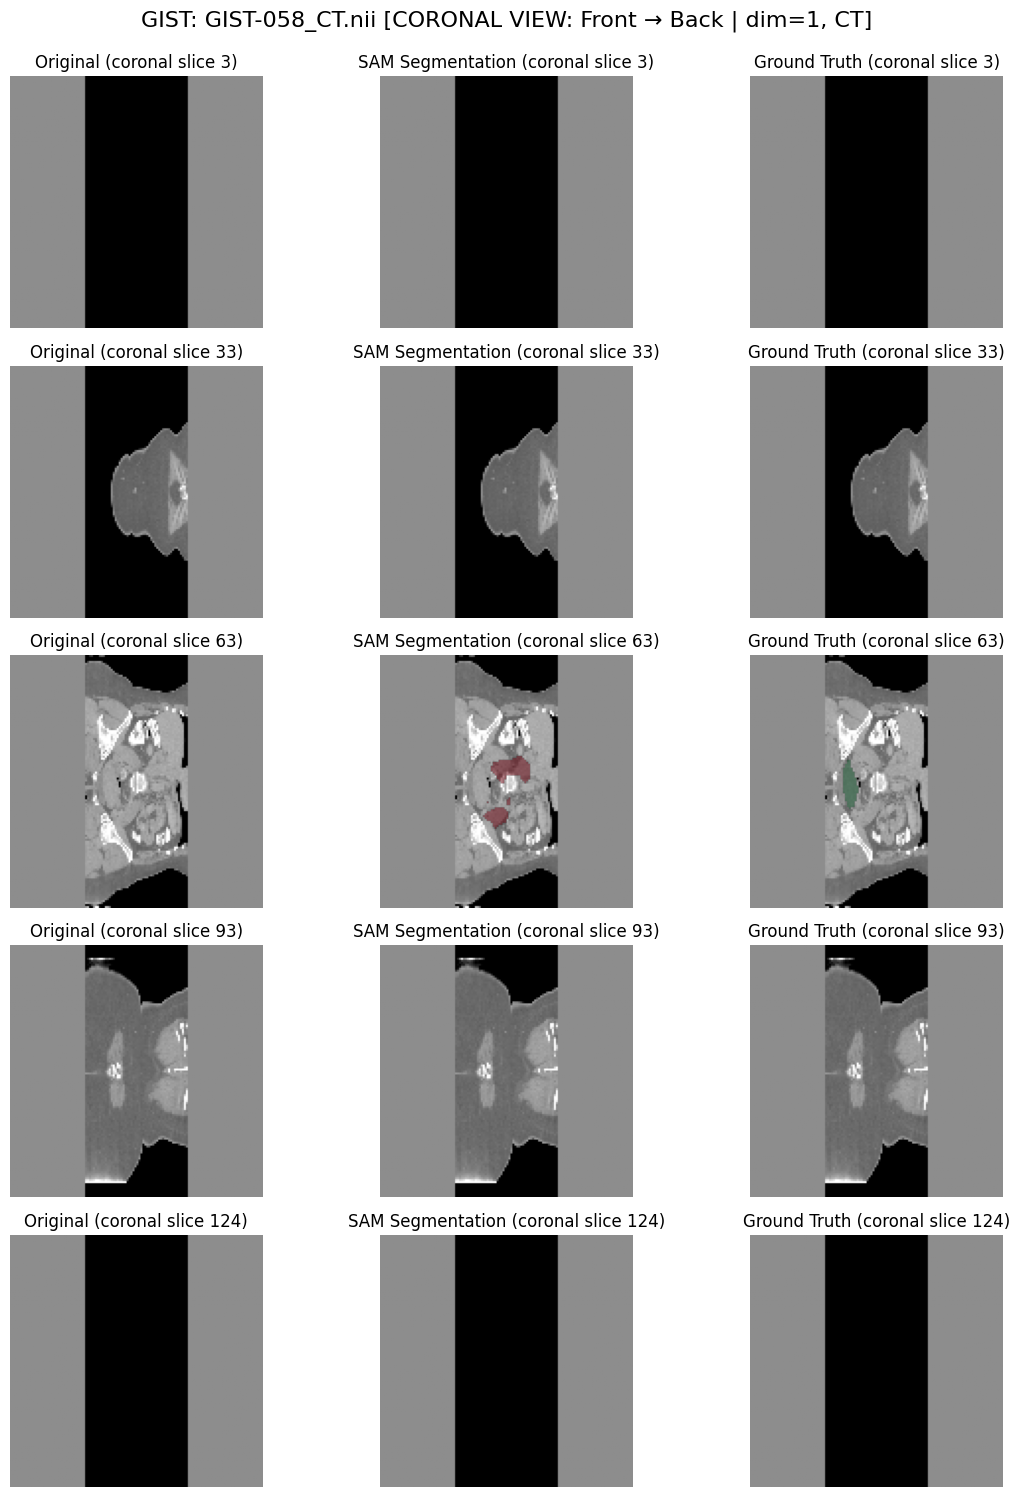


Processing: GIST-013_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 533.0 voxels
  Generating SAM segmentation...
    Using SINGLE point prompt at: (59, 80, 66)
    Segmentation stats: min=0.000, max=0.989, threshold=0.5, voxels=4796
    Segmentation sum: 4796 voxels
  Plotting CORONAL slices (front to back) [Modality: CT]...
    Skipping auto-crop (not enough padding to remove)
    Avoiding edge slices - using middle region
    Slice dimension: 1
    Content range: [0, 127]
    Selected slices: [  3  33  63  93 124]
    Display window: [-162.42, 149.58] (range: 312.00)


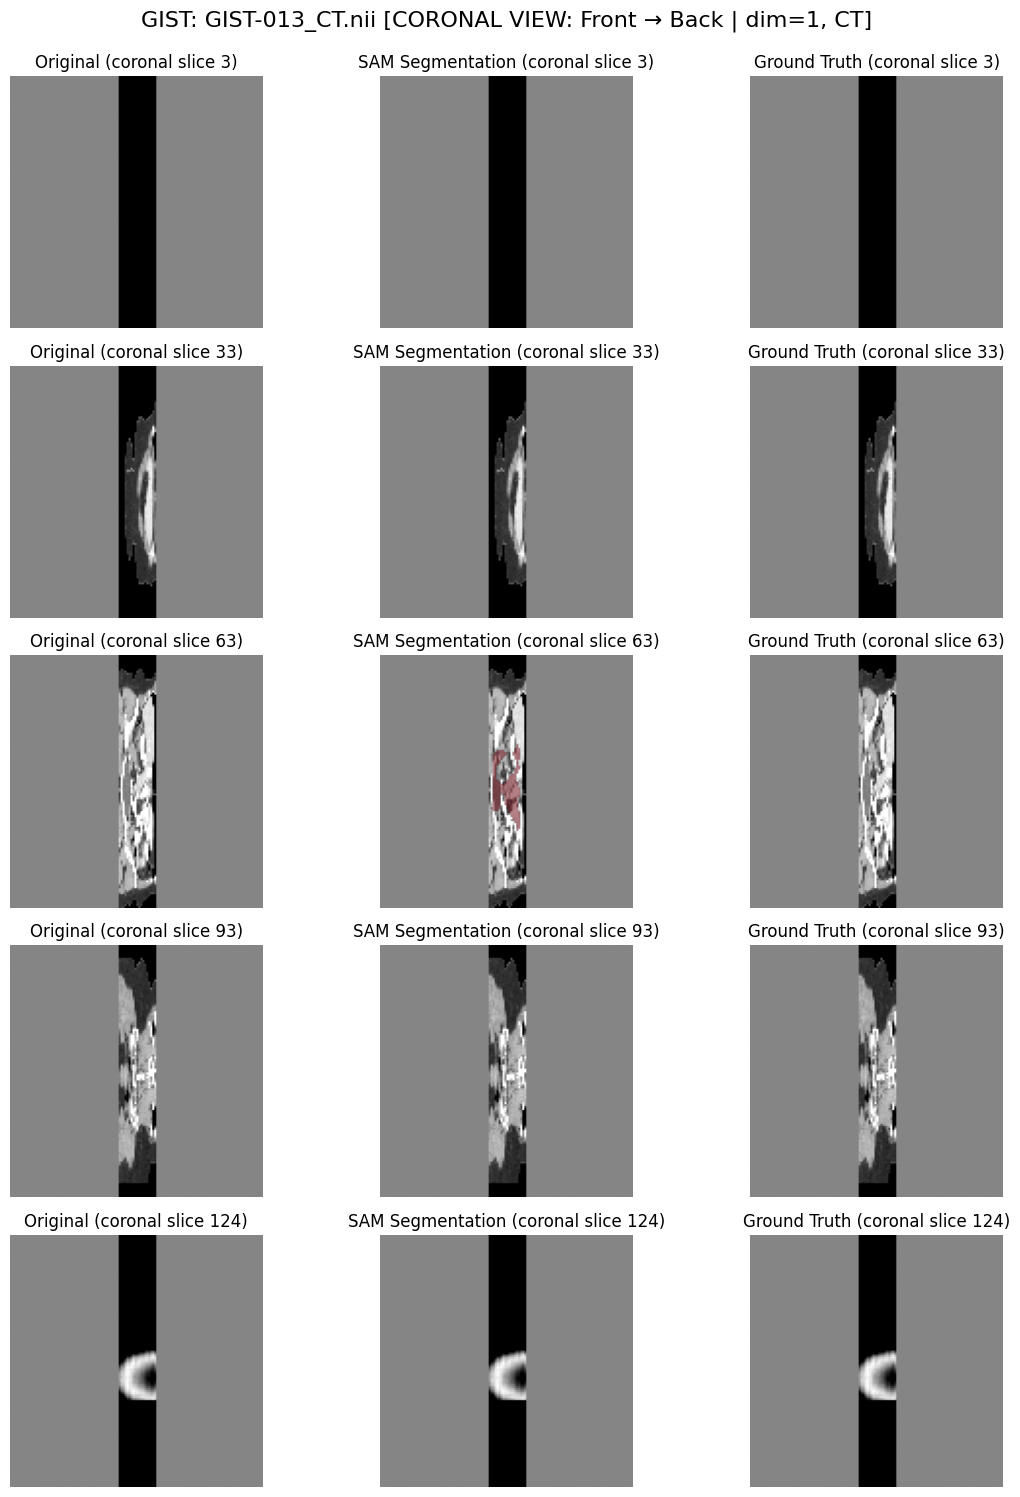


Processing dataset: LIPO
Found 138 images

Processing: Lipo-071_MR.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 881.0 voxels
  Generating SAM segmentation...
    Using SINGLE point prompt at: (63, 70, 67)
    Segmentation stats: min=0.000, max=0.999, threshold=0.5, voxels=3649
    Segmentation sum: 3649 voxels
  Plotting CORONAL slices (front to back) [Modality: MR]...
    Auto-cropped to: (107, 89, 16) - removed padding
    Slice dimension: 2
    Content range: [5, 10]
    Selected slices: [ 5  6  7  8 10]
    Display window: [168.29, 2747.50] (range: 2579.21)


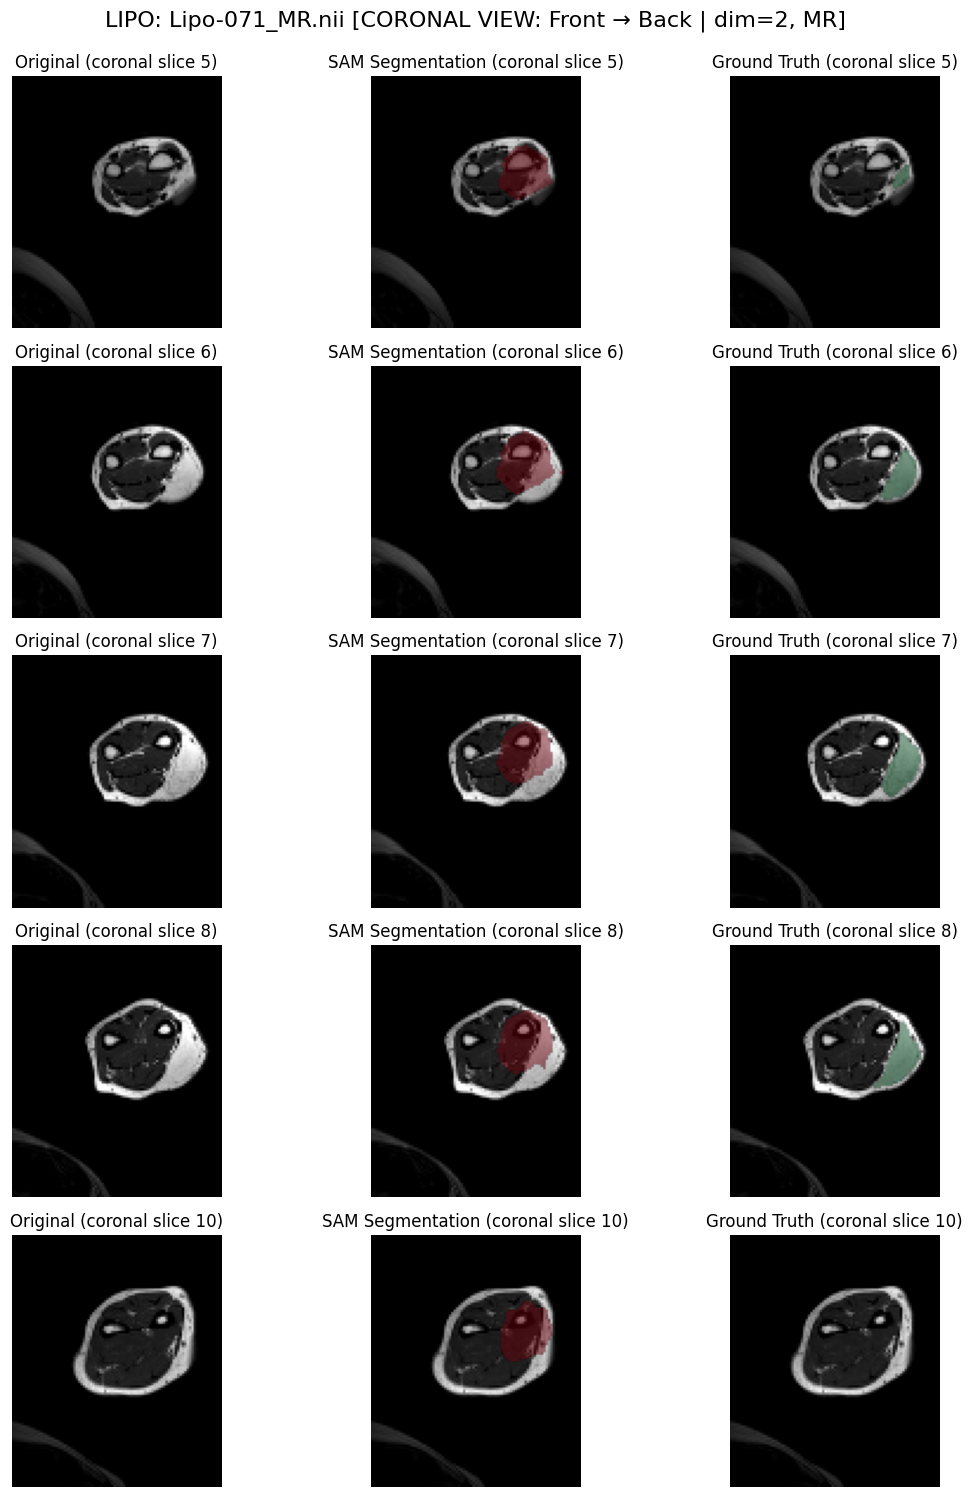


Processing: Lipo-063_MR.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 254.0 voxels
  Generating SAM segmentation...
    Using SINGLE point prompt at: (63, 67, 81)
    Segmentation stats: min=0.000, max=0.997, threshold=0.5, voxels=943
    Segmentation sum: 943 voxels
  Plotting CORONAL slices (front to back) [Modality: MR]...
    Auto-cropped to: (128, 79, 16) - removed padding
    Slice dimension: 2
    Content range: [5, 10]
    Selected slices: [ 5  6  7  8 10]
    Display window: [205.71, 2106.17] (range: 1900.46)


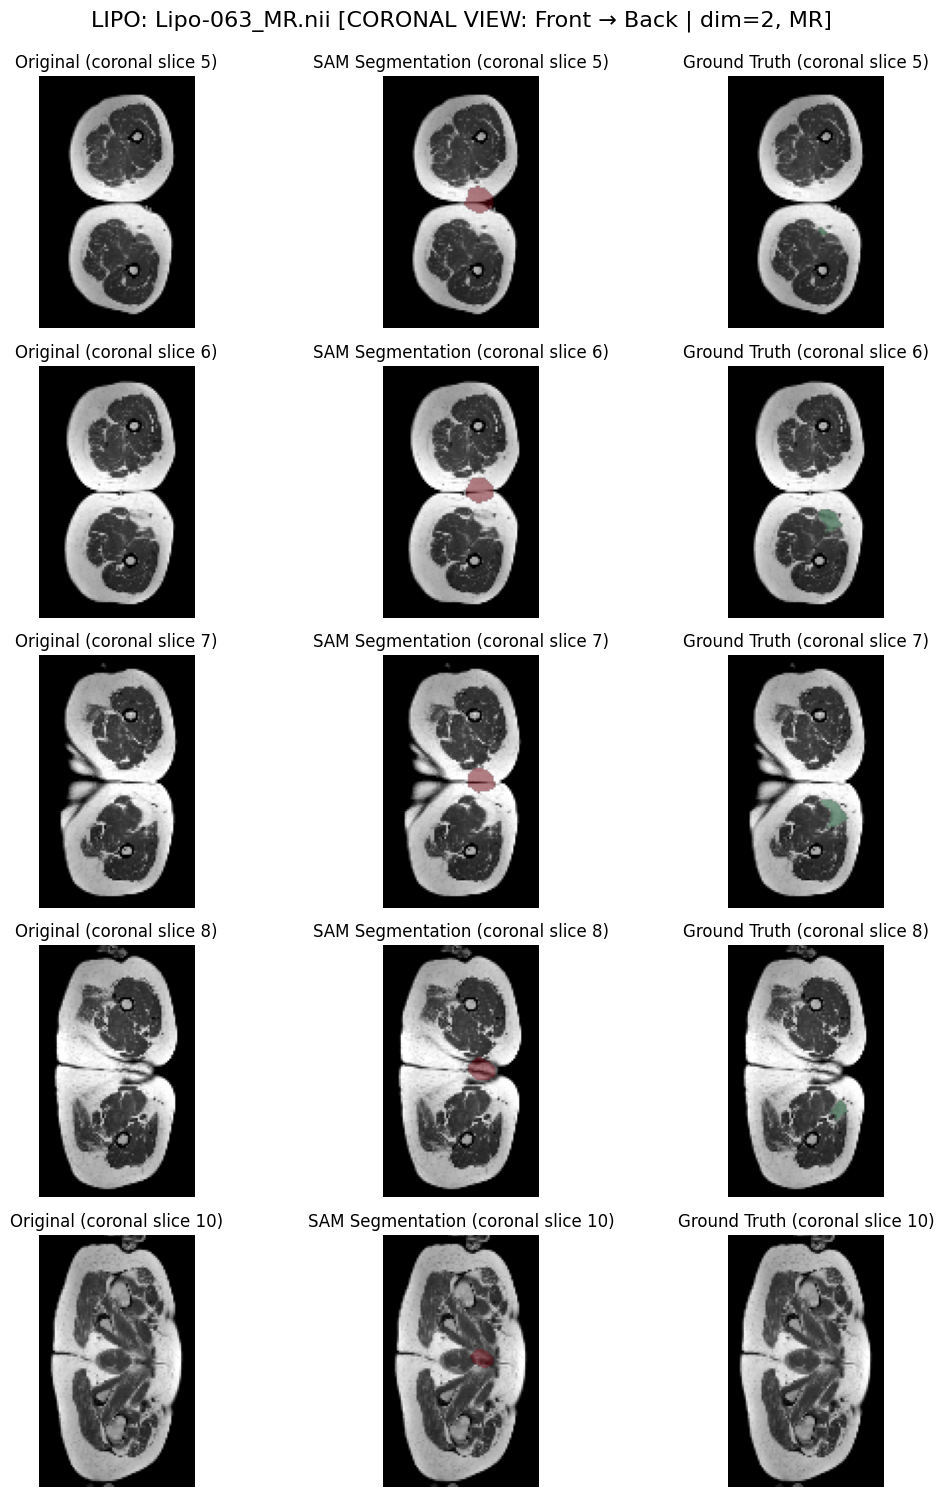

In [201]:
for dataset_name, dataset_config in config['datasets'].items():
    print("\n" + "="*60)
    print(f"Processing dataset: {dataset_name.upper()}")
    print("="*60)
    
    images, labels = find_dataset_images(dataset_config, sam3d_root, project_root)
    print(f"Found {len(images)} images")
    
    if len(images) == 0:
        print(f"  No images found for {dataset_name}")
        continue
    
    sample_indices = random.sample(range(len(images)), min(n_samples_per_dataset, len(images)))
    
    for idx in sample_indices:
        img_path = images[idx]
        label_path = labels[idx] if idx < len(labels) else None
        
        print(f"\nProcessing: {img_path.name}")
        
        try:
            print(f"  Loading image for SAM (WITH normalization)...")
            image_tensor_sam = load_volume_for_sam(img_path, img_size=img_size)
            print(f"    SAM input shape: {image_tensor_sam.shape}")
            
            print(f"  Loading image for display (NO normalization)...")
            image_vol_display = load_volume_for_display(img_path, img_size=img_size)
            print(f"    Display shape: {image_vol_display.shape}")
            
            print(f"  Loading ground truth mask...")
            gt_mask = load_mask_for_sam(label_path, img_size=img_size) if label_path else None
            if gt_mask is not None:
                print(f"    Mask shape: {gt_mask.shape}")
                print(f"    Mask sum: {gt_mask.sum()} voxels")
            
            print(f"  Generating SAM segmentation...")
            if gt_mask is not None:
                seg_mask = generate_sam_with_bbox_prompt(
                    model, image_tensor_sam, gt_mask, device, 
                    use_single_point=USE_SINGLE_POINT_PROMPT
                )
            else:
                # Fallback if no GT
                seg_mask = generate_sam_with_bbox_prompt(
                    model, image_tensor_sam, np.zeros_like(image_vol_display), device,
                    use_single_point=USE_SINGLE_POINT_PROMPT
                )
            
            print(f"    Segmentation sum: {seg_mask.sum()} voxels")
            
            # Detect modality from filename
            modality = "MR" if "_MR" in img_path.name or "Lipo" in img_path.name else "CT"
            
            print(f"  Plotting CORONAL slices (front to back) [Modality: {modality}]...")
            fig = plot_coronal_slices(
                image_vol_display,  # Use non-normalized for display
                seg_mask, 
                gt_mask,
                title=f"{dataset_name.upper()}: {img_path.stem}",
                n_slices=5,
                modality=modality  # Pass modality for correct dimension selection
            )
            plt.show()
            
        except Exception as e:
            print(f"  ❌ Error processing {img_path.name}: {e}")
            import traceback
            traceback.print_exc()

In [ ]:
print("\n" + "="*60)
print("✅ Visualization complete!")
print("="*60)
print("\nFIXES Applied:")
print("1. ✅ CORONAL view with auto-detect modality")
print("   - CT/GIST: dimension 1 (front → back)")
print("   - MR/LIPO: dimension 2 (front → back)")
print("2. ✅ Proper normalization for SAM (fixes segmentation)")
print("3. ✅ Separate display volume (unnormalized for natural look)")
print("4. ✅ Resize-then-pad preprocessing (zero data loss)")


✅ Visualization complete!

FIXES Applied:
1. ✅ CORONAL view with auto-detect modality
   - CT/GIST: dimension 1 (front → back)
   - MR/LIPO: dimension 2 (front → back)
2. ✅ Proper normalization for SAM (fixes segmentation)
3. ✅ Separate display volume (unnormalized for natural look)
4. ✅ Resize-then-pad preprocessing (zero data loss)


: 